# Advanced Predictive Modelling for Customer Churn in Banking

This notebook implements the empirical part of Duc Le's master thesis proposal using the updated
`customer_churn_1M.csv` dataset.

The research goal is to determine whether machine learning models
(`Logistic Regression`, `Decision Tree`, `Random Forest`, `XGBoost`) and deep learning models
(`ANN`, `DNN`) differ meaningfully in predictive performance, and whether any performance gain
is worth the execution-time trade-off.

Core methodological safeguards:

- The old 5,000-row proposal dataset is not used.
- Feature engineering is based on EDA from the updated 1M-row dataset.
- The final holdout test set is not used for preprocessing, encoding, resampling, tuning, or model selection.
- Target encoding is fitted inside training folds only.
- SMOTE is applied inside training folds only through `imblearn.pipeline.Pipeline`.
- Class imbalance is handled with class-weighted/cost-sensitive learning, and SMOTE is available as a leakage-safe sensitivity analysis.
- Warnings and noisy TensorFlow logs are hidden to keep the notebook readable.


## 1. Environment Setup

This cell checks the current Python environment and installs only pinned, mutually compatible
package versions if something is missing. The pins are based on the local environment checked
before generating this notebook: Python 3.12.7, pandas 2.2.2, NumPy 1.26.4, scikit-learn 1.8.0,
imbalanced-learn 0.14.1, XGBoost 3.2.0, TensorFlow 2.16.2, Keras 3.14.0, Optuna 4.8.0,
SHAP 0.46.0.

If all packages are already present with the expected versions, no installation is performed.


In [ ]:
# Environment and package installation script.
# This cell is intentionally first so later cells run with a known-compatible stack.

import importlib.metadata as importlib_metadata
import os
import subprocess
import sys
import warnings

# Hide warnings and verbose framework logs across the notebook.
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
warnings.filterwarnings("ignore")

# Exact versions verified in the current Anaconda Python 3.12 environment.
PINNED_PACKAGES = {
    "numpy": "1.26.4",
    "pandas": "2.2.2",
    "scikit-learn": "1.8.0",
    "imbalanced-learn": "0.14.1",
    "xgboost": "3.2.0",
    "tensorflow": "2.16.2",
    "keras": "3.14.0",
    "optuna": "4.8.0",
    "shap": "0.46.0",
    "seaborn": "0.13.2",
    "matplotlib": "3.9.2",
    "scipy": "1.13.1",
    "statsmodels": "0.14.2",
    "nbformat": "5.10.4",
    "ipykernel": "6.28.0",
}

INSTALL_IF_NEEDED = True


def get_installed_version(package_name: str) -> str | None:
    '''Return installed version or None if the package is missing.'''
    try:
        return importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        return None


package_status = []
packages_to_install = []

for package_name, expected_version in PINNED_PACKAGES.items():
    installed_version = get_installed_version(package_name)
    package_status.append(
        {
            "package": package_name,
            "expected": expected_version,
            "installed": installed_version or "MISSING",
            "ok": installed_version == expected_version,
        }
    )
    if installed_version != expected_version:
        packages_to_install.append(f"{package_name}=={expected_version}")

if packages_to_install and INSTALL_IF_NEEDED:
    print("Installing compatible package versions:")
    for package_spec in packages_to_install:
        print(f"  - {package_spec}")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *packages_to_install]
    )
    print("Install complete. Restart the kernel before continuing if imports fail.")
else:
    print("All required packages are already installed with compatible versions.")


Interpretation:

The table created in this cell verifies reproducibility. If packages were installed, restart the
kernel once before continuing so Python imports the newly installed versions.


## 2. Imports and Global Configuration

This section imports the full modelling stack and defines reproducibility and runtime controls.
Full-data EDA always uses all 1,000,000 rows. Model training can be run on the full data by setting
`MODEL_SAMPLE_SIZE = None`; the default sample keeps development runs practical on a laptop.


In [1]:
# Core runtime controls.
import os
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy import stats
from scipy.stats import randint, uniform
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

tf.get_logger().setLevel("ERROR")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Set this to None for final full-data thesis runs.
MODEL_SAMPLE_SIZE = None
HPO_SAMPLE_SIZE = 100_000
SMOTE_SAMPLE_SIZE = 100_000

# Keep these modest for a first complete pass; increase for final experiments.
CV_SPLITS = 3
DL_EPOCHS = 12
DL_BATCH_SIZE = 2048

RUN_HPO = True
RUN_SMOTE_SENSITIVITY = True
RUN_DEEP_LEARNING = True
RUN_SHAP = True

# A small smoke-test mode can be enabled before running the notebook:
# os.environ["CHURN_SMOKE_TEST"] = "1"
SMOKE_TEST = os.environ.get("CHURN_SMOKE_TEST") == "1"
if SMOKE_TEST:
    MODEL_SAMPLE_SIZE = 5_000
    HPO_SAMPLE_SIZE = 2_000
    SMOTE_SAMPLE_SIZE = 2_000
    CV_SPLITS = 2
    DL_EPOCHS = 2
    RUN_HPO = False
    RUN_SMOTE_SENSITIVITY = True
    RUN_DEEP_LEARNING = True
    RUN_SHAP = False

DATA_PATH = Path("customer_churn_1M.csv")
TARGET = "churn"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print(f"TensorFlow version: {tf.__version__}")
print(f"Notebook data path exists: {DATA_PATH.exists()}")


TensorFlow version: 2.16.2
Notebook data path exists: True


Interpretation:

The configuration separates thesis logic from runtime budget. EDA is not sampled. Only modelling
sample sizes are configurable so the same notebook can be used both for quick validation and final
full-data runs.


## 3. Data Loading and Schema Check

This section loads the updated CSV, checks shape, column types, duplicated rows, unique customer
IDs, and the target variable. This confirms that the proposal appendix is outdated and that the
notebook should adapt to the actual 1M-row schema.


In [2]:
# Load the full updated dataset for EDA.
df = pd.read_csv(DATA_PATH)

# Parse dates after loading so invalid date values can be counted explicitly.
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicated full rows: {df.duplicated().sum():,}")
print(f"Unique customer_id values: {df['customer_id'].nunique():,}")
print(f"Invalid signup_date values: {df['signup_date'].isna().sum():,}")

display(df.head())

schema = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100).round(3),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

display(schema)


Rows: 1,000,000
Columns: 32
Duplicated full rows: 0
Unique customer_id values: 1,000,000
Invalid signup_date values: 0


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


,dtype,n_unique,missing,missing_pct
avg_monthly_gb,float64,27482,50012,5.001
credit_score,float64,539,40395,4.040
annual_income,float64,856556,29959,2.996
num_complaints,float64,8,29906,2.991
customer_satisfaction,float64,9,19921,1.992
customer_id,object,1000000,0,0.000
signup_date,datetime64[ns],1000000,0,0.000
totalcharges,float64,427106,0,0.000
monthlycharges,float64,15896,0,0.000
days_since_last_interaction,int64,365,0,0.000


Interpretation:

The dataset has 1,000,000 customer-level observations and 32 columns. `customer_id` is unique and
must not be used as a predictive feature. `signup_date` is unique at timestamp level, so the raw
timestamp is too high-cardinality for direct modelling; it will be converted into cohort features.
Missingness is modest and concentrated in income, satisfaction, complaints, internet usage, and
credit score, so median imputation plus missingness indicators is appropriate.


## 4. Exploratory Data Analysis

EDA focuses on data quality, class imbalance, categorical churn rates, numerical churn signals,
and outliers. These findings determine the feature engineering in the next section.


,count,percent
churn,,
0,900773,90.077
1,99227,9.923


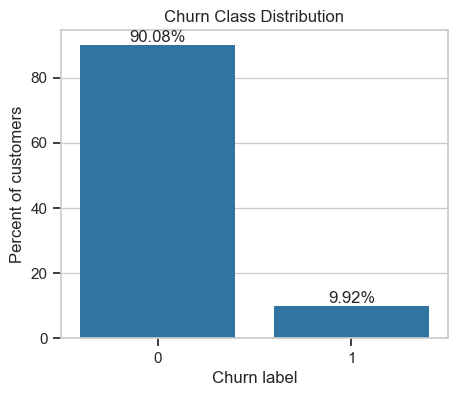

In [3]:
# Target distribution and imbalance ratio.
target_counts = df[TARGET].value_counts().sort_index()
target_pct = df[TARGET].value_counts(normalize=True).sort_index().mul(100)
target_summary = pd.DataFrame({"count": target_counts, "percent": target_pct.round(3)})
display(target_summary)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_summary.index.astype(str), y=target_summary["percent"], ax=ax)
ax.set_title("Churn Class Distribution")
ax.set_xlabel("Churn label")
ax.set_ylabel("Percent of customers")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")
plt.show()


Interpretation:

The churn class is imbalanced at roughly 10% churn and 90% non-churn. Accuracy alone would be
misleading, so recall, F1, AUC, average precision, and balanced accuracy are reported. Imbalance is
handled inside the training workflow, never by resampling the whole dataset before splitting.


,missing_count,missing_pct
avg_monthly_gb,50012,5.001
credit_score,40395,4.040
annual_income,29959,2.996
num_complaints,29906,2.991
customer_satisfaction,19921,1.992


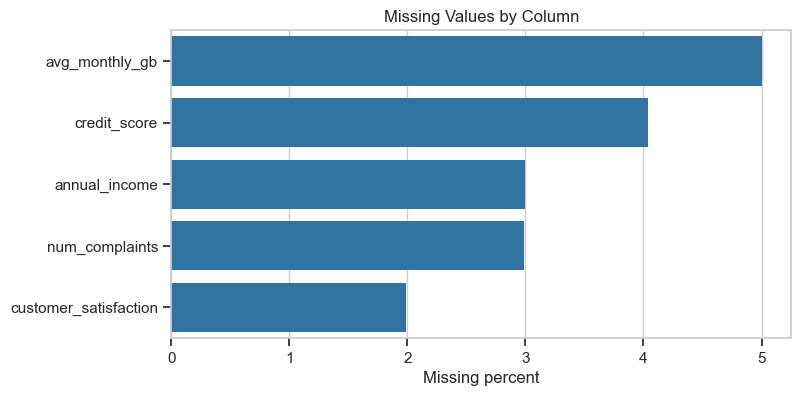

In [4]:
# Missing-value overview.
missing = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_pct": df.isna().mean().mul(100),
        }
    )
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
display(missing.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=missing.reset_index(), x="missing_pct", y="index", ax=ax)
ax.set_title("Missing Values by Column")
ax.set_xlabel("Missing percent")
ax.set_ylabel("")
plt.show()


Interpretation:

Missing values are not widespread enough to justify dropping rows. Because the variables are
financial and behavioural, median imputation is safer than mean imputation for skewed numeric
features. Missingness indicators are added for columns where being missing may itself be
informative.



gender


,count,churn_rate_pct
gender,,
Male,490166,9.928
Female,489595,9.922
Other,20239,9.823



education


,count,churn_rate_pct
education,,
master,150468,9.998
bachelor,300324,9.951
high_school,249348,9.912
phd,50250,9.908
college,249610,9.857



marital_status


...

,count,churn_rate_pct
contract,,
month_to_month,19992,26.506
one_year,550468,12.653
two_year,429540,5.652



payment_method


,count,churn_rate_pct
payment_method,,
electronic_check,250346,9.948
bank_transfer,249910,9.944
credit_card,349706,9.909
mailed_check,150038,9.879



paperless_billing


,count,churn_rate_pct
paperless_billing,,
No,250120,9.991
Yes,749880,9.900


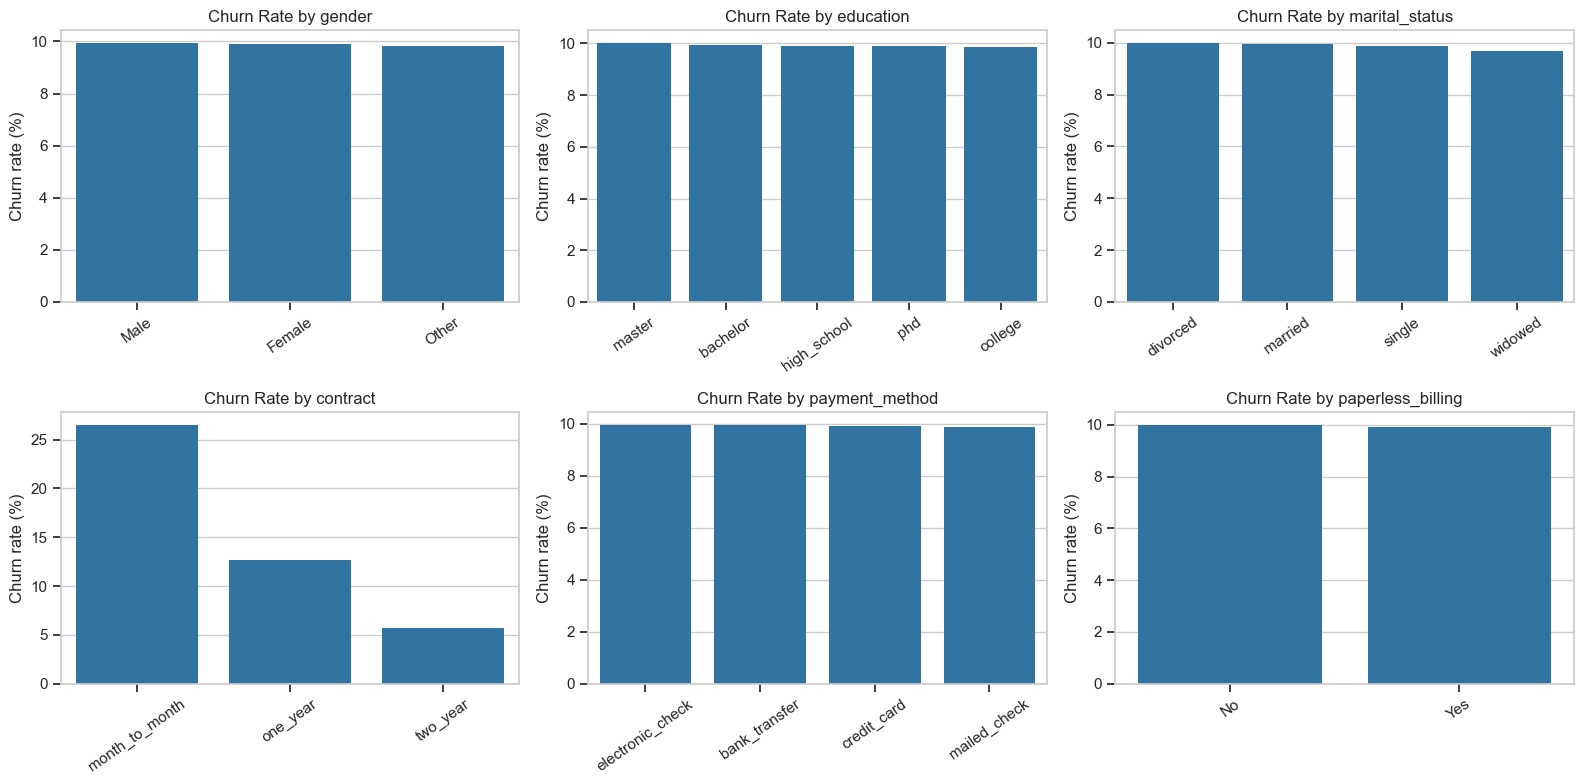

In [5]:
# Categorical churn rates.
categorical_cols = [
    "gender",
    "education",
    "marital_status",
    "contract",
    "payment_method",
    "paperless_billing",
]

cat_rate_tables = {}
for col in categorical_cols:
    table = (
        df.groupby(col, dropna=False)[TARGET]
        .agg(count="size", churn_rate="mean")
        .assign(churn_rate_pct=lambda x: x["churn_rate"].mul(100))
        .sort_values("churn_rate_pct", ascending=False)
    )
    cat_rate_tables[col] = table
    print(f"\n{col}")
    display(table[["count", "churn_rate_pct"]].round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, categorical_cols):
    plot_df = cat_rate_tables[col].reset_index()
    sns.barplot(data=plot_df, x=col, y="churn_rate_pct", ax=ax)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


Interpretation:

Contract type is the strongest categorical signal: month-to-month customers churn far more often
than one-year or two-year customers. Demographic categories have much smaller churn-rate
differences, so they are retained but not expected to dominate the models.


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,1000000.0,44.725,14.479,18.0,18.00,20.00,34.00,44.00,55.00,69.000,79.000,90.000
annual_income,970041.0,58788.312,37137.433,20000.0,20000.00,20000.00,32712.56,48954.60,73475.13,131629.390,197747.886,250000.000
dependents,1000000.0,0.800,0.894,0.0,0.00,0.00,0.00,1.00,1.00,2.000,3.000,5.000
tenure,1000000.0,22.382,20.073,1.0,1.00,1.00,6.00,16.00,33.00,71.000,72.000,72.000
senior_citizen,1000000.0,0.200,0.400,0.0,0.00,0.00,0.00,0.00,0.00,1.000,1.000,1.000
monthlycharges,1000000.0,86.444,27.592,20.0,36.91,48.82,70.49,85.48,100.68,125.180,145.200,854.957
totalcharges,1000000.0,1837.321,1803.722,16.3,53.67,87.46,484.53,1249.75,2617.66,5673.051,7785.641,16252.862
num_services,1000000.0,2.564,1.412,1.0,1.00,1.00,1.00,2.00,3.00,5.000,6.000,6.000
has_phone_service,1000000.0,0.770,0.421,0.0,0.00,0.00,1.00,1.00,1.00,1.000,1.000,1.000
has_internet_service,1000000.0,0.850,0.357,0.0,0.00,0.00,1.00,1.00,1.00,1.000,1.000,1.000


,corr_with_churn
customer_satisfaction,-0.0847
num_complaints,0.0800
num_service_calls,0.0773
late_payments,0.0477
has_tech_support,-0.0455
has_online_security,-0.0341
num_services,-0.0334
totalcharges,-0.0165
has_internet_service,-0.0153
monthlycharges,-0.0138


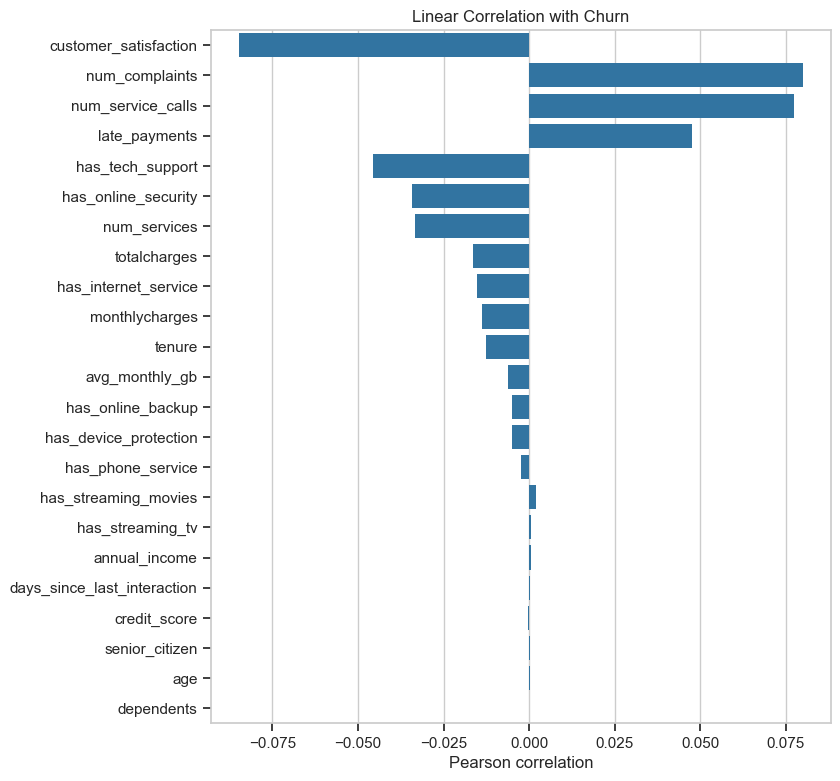

In [6]:
# Numerical summary and correlation with churn.
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET).tolist()

numeric_summary = df[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
display(numeric_summary.round(3))

target_corr = (
    df[numeric_cols]
    .corrwith(df[TARGET])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_churn")
)
display(target_corr.round(4))

fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(
    data=target_corr.reset_index(),
    y="index",
    x="corr_with_churn",
    ax=ax,
)
ax.set_title("Linear Correlation with Churn")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")
plt.show()


Interpretation:

Linear correlations are moderate, which supports testing non-linear models. Satisfaction is
negatively associated with churn, while complaints, service calls, and late payments are positively
associated. These patterns motivate engineered features that combine dissatisfaction, support
contact intensity, payment behaviour, and account tenure.


,feature,bin,count,churn_rate_pct
0,customer_satisfaction,"(-0.001, 2.0]",88532,16.237
1,customer_satisfaction,"(2.0, 4.0]",156704,12.464
2,customer_satisfaction,"(4.0, 6.0]",235139,9.833
3,customer_satisfaction,"(6.0, 8.0]",313424,8.393
4,customer_satisfaction,"(8.0, 10.0]",186280,7.482
5,num_complaints,"(-1.001, 0.0]",481239,8.096
6,num_complaints,"(0.0, 1.0]",336819,10.463
7,num_complaints,"(1.0, 2.0]",118816,13.404
8,num_complaints,"(2.0, 8.0]",33220,18.450
9,num_service_calls,"(-1.001, 0.0]",204894,7.709


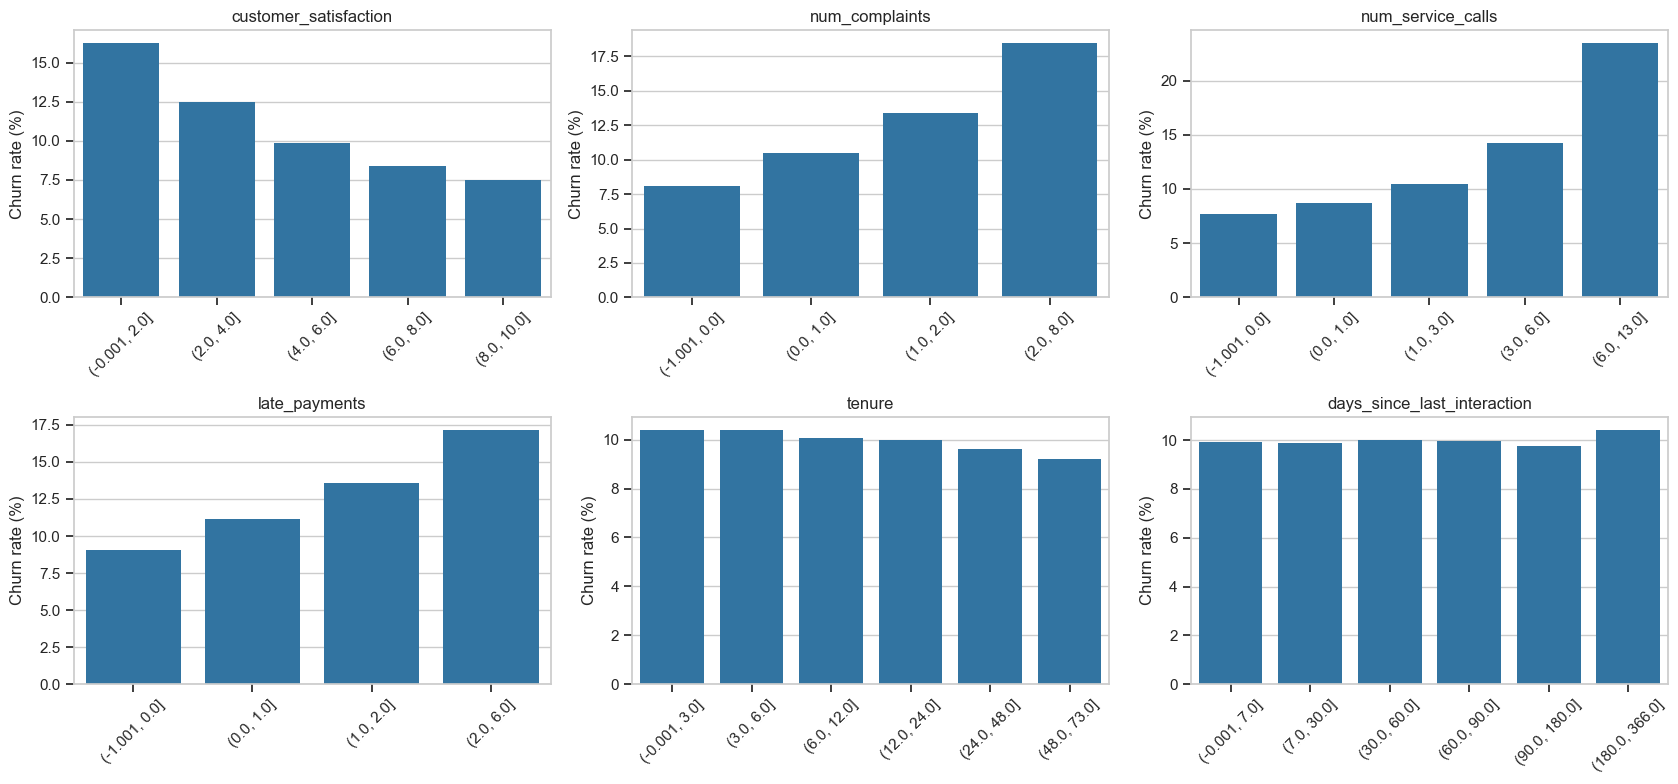

In [7]:
# Binned churn rates for selected high-signal variables.
bin_specs = {
    "customer_satisfaction": [0, 2, 4, 6, 8, 10],
    "num_complaints": [-1, 0, 1, 2, 8],
    "num_service_calls": [-1, 0, 1, 3, 6, 13],
    "late_payments": [-1, 0, 1, 2, 6],
    "tenure": [0, 3, 6, 12, 24, 48, 73],
    "days_since_last_interaction": [0, 7, 30, 60, 90, 180, 366],
}

binned_tables = []
for col, bins in bin_specs.items():
    tmp = df[[col, TARGET]].copy()
    tmp[f"{col}_bin"] = pd.cut(tmp[col], bins=bins, include_lowest=True)
    table = (
        tmp.groupby(f"{col}_bin", observed=False)[TARGET]
        .agg(count="size", churn_rate="mean")
        .reset_index()
    )
    table["feature"] = col
    table["bin"] = table[f"{col}_bin"].astype(str)
    table["churn_rate_pct"] = table["churn_rate"].mul(100)
    binned_tables.append(table[["feature", "bin", "count", "churn_rate_pct"]])

binned_df = pd.concat(binned_tables, ignore_index=True)
display(binned_df.round(3))

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.ravel()
for ax, col in zip(axes, bin_specs):
    plot_df = binned_df[binned_df["feature"] == col]
    sns.barplot(data=plot_df, x="bin", y="churn_rate_pct", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


Interpretation:

The binned plots show monotonic churn-risk patterns for dissatisfaction, complaints, service calls,
late payments, and tenure. These are good candidates for interaction features such as complaint
pressure, service-contact intensity, and late-payment rate per tenure month.


## 5. Leakage-Safe Methodology

The main leakage risks in this study are:

- Learning imputers, scalers, encoders, or synthetic samples from the full dataset before splitting.
- Target encoding high-cardinality categories outside the cross-validation fold.
- Applying SMOTE before train-test split or before cross-validation.
- Using unique IDs or raw timestamps as model inputs.

The notebook prevents these issues by building all preprocessing steps inside scikit-learn or
imbalanced-learn pipelines. `TargetEncoder` uses internal cross-fitting during `fit_transform`, and
SMOTE is placed inside an `imblearn.pipeline.Pipeline`, so it runs only on the training portion of
each fold. These choices follow scikit-learn's target encoding guidance and imbalanced-learn's
data leakage recommendations.


In [8]:
# Stratified final holdout split.
# The test set is kept untouched until final model evaluation.

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train rows: {len(X_train_full):,}")
print(f"Test rows : {len(X_test):,}")
print("Train churn rate:", round(y_train_full.mean() * 100, 3), "%")
print("Test churn rate :", round(y_test.mean() * 100, 3), "%")


Train rows: 800,000
Test rows : 200,000
Train churn rate: 9.923 %
Test churn rate : 9.922 %


Interpretation:

The final test set keeps the natural churn distribution. It is not balanced, encoded, imputed, or
used for model selection. This gives a realistic estimate of deployment performance.


## 6. Feature Engineering

Feature engineering is based on the observed 1M-row data rather than the outdated proposal
appendix. The raw ID is dropped. The raw timestamp is transformed into interpretable cohort
variables. Behavioural and financial ratios are added because EDA showed churn is linked to
contract type, dissatisfaction, complaints, service calls, late payments, and tenure.


In [9]:
class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    '''Create EDA-driven features without using the target variable.'''

    def fit(self, X, y=None):
        # No statistics are learned here, so there is no target or fold leakage.
        return self

    def transform(self, X):
        X = X.copy()

        # Convert signup timestamp into cohort features; drop the raw high-cardinality timestamp later.
        signup = pd.to_datetime(X["signup_date"], errors="coerce")
        X["signup_year"] = signup.dt.year.astype("Int64").astype(str).replace("<NA>", "missing")
        X["signup_month"] = signup.dt.month.astype("Int64").astype(str).replace("<NA>", "missing")
        X["signup_quarter"] = signup.dt.quarter.astype("Int64").astype(str).replace("<NA>", "missing")
        X["signup_year_month"] = signup.dt.to_period("M").astype(str).replace("NaT", "missing")

        # Safe denominators prevent divide-by-zero errors and leave NaNs for the imputer.
        tenure_safe = X["tenure"].replace(0, np.nan)
        income_safe = X["annual_income"].replace(0, np.nan)

        # Financial burden and charge consistency features.
        X["charges_per_tenure"] = X["totalcharges"] / tenure_safe
        X["monthly_charge_gap"] = X["monthlycharges"] - X["charges_per_tenure"]
        X["annualized_charge_income_ratio"] = (X["monthlycharges"] * 12) / income_safe
        X["total_charge_income_ratio"] = X["totalcharges"] / income_safe

        # Complaint and support intensity features.
        X["complaint_rate_per_call"] = X["num_complaints"] / (X["num_service_calls"] + 1)
        X["support_contact_intensity"] = X["num_service_calls"] / tenure_safe
        X["late_payment_rate"] = X["late_payments"] / tenure_safe
        X["recency_tenure_ratio"] = X["days_since_last_interaction"] / (tenure_safe * 30)

        # Service bundle features.
        service_cols = [
            "has_phone_service",
            "has_internet_service",
            "has_online_security",
            "has_online_backup",
            "has_device_protection",
            "has_tech_support",
            "has_streaming_tv",
            "has_streaming_movies",
        ]
        X["enabled_service_count"] = X[service_cols].sum(axis=1)
        X["protection_support_count"] = X[
            ["has_online_security", "has_online_backup", "has_device_protection", "has_tech_support"]
        ].sum(axis=1)
        X["streaming_count"] = X[["has_streaming_tv", "has_streaming_movies"]].sum(axis=1)
        X["service_adoption_ratio"] = X["num_services"] / 6

        # Dissatisfaction interaction features.
        X["satisfaction_risk"] = 10 - X["customer_satisfaction"]
        X["complaint_satisfaction_pressure"] = X["num_complaints"] * X["satisfaction_risk"]
        X["low_satisfaction_flag"] = (X["customer_satisfaction"] <= 4).astype(float)
        X["complaint_flag"] = (X["num_complaints"] > 0).astype(float)
        X["low_satisfaction_with_complaint"] = (
            X["low_satisfaction_flag"] * X["complaint_flag"]
        )

        # Missingness indicators preserve potential information from missing values.
        for col in [
            "annual_income",
            "customer_satisfaction",
            "num_complaints",
            "avg_monthly_gb",
            "credit_score",
        ]:
            X[f"{col}_was_missing"] = X[col].isna().astype(int)

        # Drop direct identifiers and raw timestamp.
        return X.drop(columns=["customer_id", "signup_date"], errors="ignore")


Interpretation:

This transformer uses only information available in each row. It does not compute target rates,
global means, or dataset-level statistics. That keeps engineered features safe for cross-validation
and final holdout testing.


In [10]:
# Feature groups after feature engineering.
NUMERIC_FEATURES = [
    "age",
    "annual_income",
    "dependents",
    "tenure",
    "senior_citizen",
    "monthlycharges",
    "totalcharges",
    "num_services",
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies",
    "customer_satisfaction",
    "num_complaints",
    "num_service_calls",
    "late_payments",
    "avg_monthly_gb",
    "days_since_last_interaction",
    "credit_score",
    "charges_per_tenure",
    "monthly_charge_gap",
    "annualized_charge_income_ratio",
    "total_charge_income_ratio",
    "complaint_rate_per_call",
    "support_contact_intensity",
    "late_payment_rate",
    "recency_tenure_ratio",
    "enabled_service_count",
    "protection_support_count",
    "streaming_count",
    "service_adoption_ratio",
    "satisfaction_risk",
    "complaint_satisfaction_pressure",
    "low_satisfaction_flag",
    "complaint_flag",
    "low_satisfaction_with_complaint",
    "annual_income_was_missing",
    "customer_satisfaction_was_missing",
    "num_complaints_was_missing",
    "avg_monthly_gb_was_missing",
    "credit_score_was_missing",
]

LOW_CARD_CATEGORICAL_FEATURES = [
    "gender",
    "education",
    "marital_status",
    "contract",
    "payment_method",
    "paperless_billing",
    "signup_year",
    "signup_month",
    "signup_quarter",
]

# Target-encoded feature. The raw timestamp is not encoded; the monthly cohort is.
HIGH_CARD_CATEGORICAL_FEATURES = ["signup_year_month"]


def make_column_transformer():
    '''Create the preprocessing column transformer used inside every model pipeline.'''
    numeric_pipe = SkPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    low_card_pipe = SkPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    high_card_pipe = SkPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "target_encoder",
                TargetEncoder(
                    target_type="binary",
                    smooth="auto",
                    cv=CV_SPLITS,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, NUMERIC_FEATURES),
            ("low_card", low_card_pipe, LOW_CARD_CATEGORICAL_FEATURES),
            ("target_encoded", high_card_pipe, HIGH_CARD_CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_preprocess_steps():
    '''Return top-level steps so imblearn Pipeline does not receive a nested Pipeline.'''
    return [
        ("feature_engineering", ChurnFeatureEngineer()),
        ("preprocess", make_column_transformer()),
    ]


preprocess_preview = SkPipeline(make_preprocess_steps())
sample_preview = preprocess_preview.fit_transform(X_train_full.head(2_000), y_train_full.head(2_000))
print("Preview transformed shape:", sample_preview.shape)


Preview transformed shape: (2000, 89)


Interpretation:

The preview confirms that the custom feature engineering and column transformer produce a numeric
matrix suitable for all ML and DL models. Target encoding is part of the transformer and will be
re-fitted within each fold.


## 7. Modelling Samples

The full training set is available for final thesis runs. For iterative notebook development, a
stratified modelling sample reduces runtime while preserving the churn ratio.


In [11]:
def stratified_sample(X_data, y_data, sample_size, random_state=RANDOM_STATE):
    '''Return a stratified sample, or the original data if sample_size is None.'''
    if sample_size is None or sample_size >= len(X_data):
        return X_data.copy(), y_data.copy()

    _, X_sample, _, y_sample = train_test_split(
        X_data,
        y_data,
        test_size=sample_size,
        stratify=y_data,
        random_state=random_state,
    )
    return X_sample.copy(), y_sample.copy()


X_model, y_model = stratified_sample(X_train_full, y_train_full, MODEL_SAMPLE_SIZE)
X_hpo, y_hpo = stratified_sample(X_train_full, y_train_full, HPO_SAMPLE_SIZE)
X_smote, y_smote = stratified_sample(X_train_full, y_train_full, SMOTE_SAMPLE_SIZE)

print(f"Model sample rows: {len(X_model):,} | churn rate: {y_model.mean() * 100:.3f}%")
print(f"HPO sample rows  : {len(X_hpo):,} | churn rate: {y_hpo.mean() * 100:.3f}%")
print(f"SMOTE rows       : {len(X_smote):,} | churn rate: {y_smote.mean() * 100:.3f}%")


Model sample rows: 800,000 | churn rate: 9.923%
HPO sample rows  : 100,000 | churn rate: 9.923%
SMOTE rows       : 100,000 | churn rate: 9.923%


Interpretation:

All modelling subsets are drawn only from the training partition and preserve the churn ratio.
The final test set remains untouched.


## 8. Evaluation Utilities

This section defines reusable evaluation functions. Each fold fits a fresh pipeline so preprocessing,
target encoding, and optional SMOTE are learned only from the fold's training data.


In [12]:
def calculate_scale_pos_weight(y_data):
    '''Return negative-to-positive class ratio for XGBoost.'''
    positives = int((y_data == 1).sum())
    negatives = int((y_data == 0).sum())
    return negatives / max(positives, 1)


def build_ml_models(y_reference):
    '''Create the four ML models with class imbalance handling.'''
    xgb_weight = calculate_scale_pos_weight(y_reference)

    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1_000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=160,
            max_depth=14,
            min_samples_leaf=50,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.06,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=xgb_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0,
        ),
    }


def make_ml_pipeline(model, use_smote=False):
    '''Build one complete pipeline with optional leakage-safe SMOTE.'''
    steps = make_preprocess_steps()
    if use_smote:
        steps.append(
            (
                "smote",
                SMOTE(
                    sampling_strategy=0.35,
                    k_neighbors=5,
                    random_state=RANDOM_STATE,
                ),
            )
        )
    steps.append(("model", model))
    return ImbPipeline(steps=steps)


def predict_positive_probability(fitted_model, X_data):
    '''Return positive-class probabilities for estimators with either predict_proba or decision_function.'''
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_data)[:, 1]
    scores = fitted_model.decision_function(X_data)
    return 1 / (1 + np.exp(-scores))


def metric_dict(y_true, y_pred, y_proba):
    '''Compute churn metrics with zero-division protection.'''
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "avg_precision": average_precision_score(y_true, y_proba),
    }


def evaluate_pipeline_cv(name, pipeline, X_data, y_data, cv_splits=CV_SPLITS):
    '''Evaluate a sklearn/imblearn pipeline with timed stratified CV.'''
    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    rows = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_data), start=1):
        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        fitted = clone(pipeline)

        fit_start = time.perf_counter()
        fitted.fit(X_train_fold, y_train_fold)
        fit_seconds = time.perf_counter() - fit_start

        pred_start = time.perf_counter()
        y_proba = predict_positive_probability(fitted, X_valid_fold)
        y_pred = (y_proba >= 0.50).astype(int)
        predict_seconds = time.perf_counter() - pred_start

        row = {
            "model": name,
            "fold": fold,
            "train_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
            "predict_ms_per_1000": predict_seconds / len(X_valid_fold) * 1000 * 1000,
        }
        row.update(metric_dict(y_valid_fold, y_pred, y_proba))
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_cv_results(cv_results):
    '''Summarize fold-level metrics as mean and standard deviation.'''
    metric_cols = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "avg_precision",
        "train_seconds",
        "predict_ms_per_1000",
    ]
    summary = cv_results.groupby("model")[metric_cols].agg(["mean", "std"])
    return summary.sort_values(("recall", "mean"), ascending=False)


Interpretation:

The evaluation utility returns fold-level metrics, not just averages. This is important because
statistical comparison later uses fold-level distributions.


## 9. Machine Learning Benchmark

The primary ML benchmark uses class-weighted or cost-sensitive learning for all four models.
This is the fairest default for 1M rows because it handles imbalance without changing the natural
feature distribution. A separate SMOTE sensitivity experiment follows.


In [13]:
ml_models = build_ml_models(y_model)
ml_cv_results = []

for model_name, estimator in ml_models.items():
    print(f"Evaluating {model_name}...")
    pipeline = make_ml_pipeline(estimator, use_smote=False)
    result = evaluate_pipeline_cv(model_name, pipeline, X_model, y_model)
    ml_cv_results.append(result)

ml_cv_results = pd.concat(ml_cv_results, ignore_index=True)
display(ml_cv_results.round(4))

ml_summary = summarize_cv_results(ml_cv_results)
display(ml_summary.round(4))


Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating XGBoost...


,model,fold,train_seconds,predict_seconds,predict_ms_per_1000,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,avg_precision
0,Logistic Regression,1,7.2099,1.0611,3.9792,0.6315,0.6357,0.1604,0.6410,0.2566,0.6873,0.2028
1,Logistic Regression,2,6.2475,1.2059,4.5222,0.6291,0.6321,0.1586,0.6358,0.2539,0.6830,0.2001
2,Logistic Regression,3,7.3535,1.0976,4.1159,0.6267,0.6336,0.1587,0.6421,0.2545,0.6853,0.2022
3,Decision Tree,1,14.7627,0.9736,3.6511,0.6320,0.6226,0.1554,0.6108,0.2478,0.6685,0.1849
4,Decision Tree,2,14.7119,0.9958,3.7344,0.6094,0.6183,0.1501,0.6294,0.2423,0.6646,0.1826
5,Decision Tree,3,13.8740,0.8849,3.3185,0.6214,0.6181,0.1518,0.6139,0.2435,0.6642,0.1806
6,Random Forest,1,46.9929,1.6589,6.2210,0.6800,0.6313,0.1695,0.5704,0.2613,0.6834,0.1989
7,Random Forest,2,46.9590,1.6944,6.3541,0.6742,0.6285,0.1668,0.5716,0.2582,0.6799,0.1959
8,Random Forest,3,48.1246,1.6080,6.0299,0.6749,0.6273,0.1665,0.5680,0.2575,0.6815,0.1988
9,XGBoost,1,8.9577,0.9339,3.5020,0.6348,0.6360,0.1612,0.6376,0.2573,0.6880,0.2054


accuracy         balanced_accuracy         precision  \
                        mean     std              mean     std      mean   
model                                                                      
Logistic Regression   0.6291  0.0024            0.6338  0.0018    0.1592   
XGBoost               0.6326  0.0019            0.6349  0.0012    0.1603   
Decision Tree         0.6209  0.0113            0.6197  0.0025    0.1524   
Random Forest         0.6764  0.0032            0.6290  0.0020    0.1676   

                             recall              f1         roc_auc          \
                        std    mean     std    mean     std    mean     std   
model                                                                         
Logistic Regression  0.0010  0.6397  0.0034  0.2550  0.0015  0.6852  0.0021   
XGBoost              0.0008  0.6378  0.0012  0.2562  0.0011  0.6862  0.0019   
Decision Tree        0.0027  0.6180  0.0100  0.2445  0.0029  0.6658  0.0024   
Random Forest        0.0017  0.5700  0.0019  0.2590  0.0021  0.6816  0.0018   

                    avg_precision         train_seconds          \
                             mean     std          mean     std   
model                                                             
Logistic Regression        0.2017  0.0014        6.9370  0.6014   
XGBoost                    0.2050  0.0015        8.6436  0.2726   
Decision Tree              0.1827  0.0021       14.4495  0.4991   
Random Forest              0.1979  0.0017       47.3588  0.6634   

                    predict_ms_per_1000          
                                   mean     std  
model                                            
Logistic Regression              4.2058  0.2825  
XGBoost                          3.5527  0.0464  
Decision Tree                    3.5680  0.2201  
Random Forest                    6.2017  0.1630

Interpretation:

Compare recall and F1 first because churn is imbalanced and missed churners are costly. Then check
ROC-AUC, average precision, and execution time to decide whether a more complex model is worth
its runtime cost.


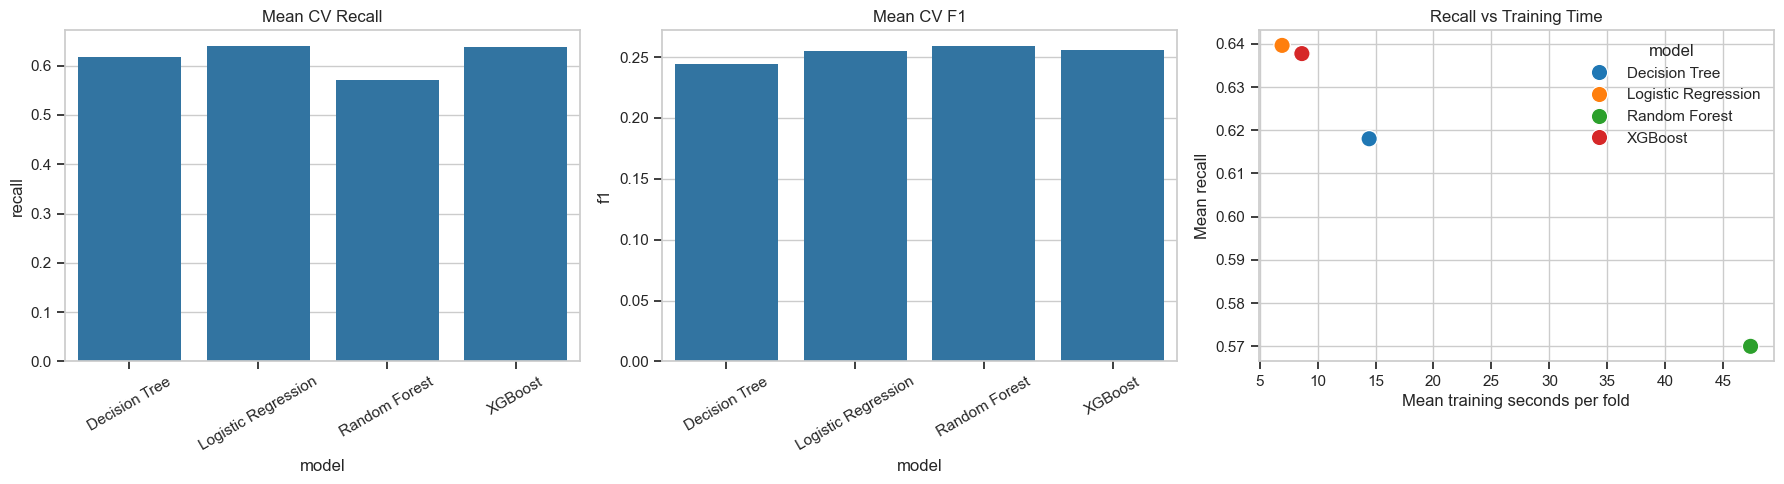

In [14]:
# Visual comparison of predictive performance and runtime.
plot_df = (
    ml_cv_results.groupby("model")
    .agg(
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        roc_auc=("roc_auc", "mean"),
        train_seconds=("train_seconds", "mean"),
        predict_ms_per_1000=("predict_ms_per_1000", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=plot_df, x="model", y="recall", ax=axes[0])
axes[0].set_title("Mean CV Recall")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=plot_df, x="model", y="f1", ax=axes[1])
axes[1].set_title("Mean CV F1")
axes[1].tick_params(axis="x", rotation=30)

sns.scatterplot(
    data=plot_df,
    x="train_seconds",
    y="recall",
    hue="model",
    s=140,
    ax=axes[2],
)
axes[2].set_title("Recall vs Training Time")
axes[2].set_xlabel("Mean training seconds per fold")
axes[2].set_ylabel("Mean recall")
plt.tight_layout()
plt.show()


Interpretation:

The scatter plot directly addresses the thesis trade-off question: a model is attractive only if
its recall/F1 improvement justifies its additional training and prediction time.


## 10. Leakage-Safe SMOTE Sensitivity Analysis

This section tests whether SMOTE improves churn detection. SMOTE is inside the pipeline, so it is
fit only on the training part of each CV fold. The validation fold keeps the original imbalanced
distribution.


In [15]:
if RUN_SMOTE_SENSITIVITY:
    smote_results = []
    smote_models = build_ml_models(y_smote)

    for model_name, estimator in smote_models.items():
        print(f"Evaluating SMOTE + {model_name}...")
        pipeline = make_ml_pipeline(estimator, use_smote=True)
        result = evaluate_pipeline_cv(f"SMOTE + {model_name}", pipeline, X_smote, y_smote)
        smote_results.append(result)

    smote_cv_results = pd.concat(smote_results, ignore_index=True)
    display(smote_cv_results.round(4))
    display(summarize_cv_results(smote_cv_results).round(4))
else:
    smote_cv_results = pd.DataFrame()
    print("SMOTE sensitivity analysis skipped.")


Evaluating SMOTE + Logistic Regression...
Evaluating SMOTE + Decision Tree...
Evaluating SMOTE + Random Forest...
Evaluating SMOTE + XGBoost...


,model,fold,train_seconds,predict_seconds,predict_ms_per_1000,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,avg_precision
0,SMOTE + Logistic Regression,1,1.4558,0.2377,7.1306,0.6264,0.6310,0.1577,0.6366,0.2527,0.6854,0.2008
1,SMOTE + Logistic Regression,2,1.1687,0.2148,6.4453,0.6248,0.6263,0.1556,0.6281,0.2494,0.6798,0.1938
2,SMOTE + Logistic Regression,3,1.2644,0.2007,6.0200,0.6288,0.6258,0.1561,0.6221,0.2496,0.6756,0.1998
3,SMOTE + Decision Tree,1,1.9324,0.1398,4.1927,0.8249,0.5592,0.1866,0.2276,0.2051,0.6412,0.1543
4,SMOTE + Decision Tree,2,1.9127,0.1476,4.4287,0.8260,0.5590,0.1874,0.2259,0.2049,0.6341,0.1496
5,SMOTE + Decision Tree,3,1.9947,0.1268,3.8043,0.8193,0.5597,0.1824,0.2358,0.2057,0.6382,0.1531
6,SMOTE + Random Forest,1,5.6907,0.2377,7.1302,0.8845,0.5391,0.2844,0.1082,0.1568,0.6799,0.1927
7,SMOTE + Random Forest,2,6.0391,0.1958,5.8740,0.8781,0.5404,0.2550,0.1191,0.1624,0.6702,0.1833
8,SMOTE + Random Forest,3,4.9176,0.2007,6.0201,0.8776,0.5428,0.2588,0.1252,0.1687,0.6700,0.1867
9,SMOTE + XGBoost,1,1.7409,0.1255,3.7661,0.6169,0.6354,0.1576,0.6584,0.2543,0.6861,0.2060


accuracy         balanced_accuracy          \
                                mean     std              mean     std   
model                                                                    
SMOTE + XGBoost               0.6126  0.0037            0.6292  0.0053   
SMOTE + Logistic Regression   0.6267  0.0020            0.6277  0.0028   
SMOTE + Decision Tree         0.8234  0.0036            0.5593  0.0004   
SMOTE + Random Forest         0.8800  0.0038            0.5408  0.0019   

                            precision          recall              f1          \
                                 mean     std    mean     std    mean     std   
model                                                                           
SMOTE + XGBoost                0.1546  0.0026  0.6499  0.0074  0.2498  0.0039   
SMOTE + Logistic Regression    0.1565  0.0011  0.6289  0.0073  0.2506  0.0019   
SMOTE + Decision Tree          0.1855  0.0027  0.2298  0.0053  0.2052  0.0004   
SMOTE + Random Forest          0.2660  0.0160  0.1175  0.0086  0.1626  0.0060   

                            roc_auc         avg_precision          \
                               mean     std          mean     std   
model                                                               
SMOTE + XGBoost              0.6793  0.0060        0.1977  0.0079   
SMOTE + Logistic Regression  0.6803  0.0049        0.1981  0.0038   
SMOTE + Decision Tree        0.6378  0.0036        0.1523  0.0024   
SMOTE + Random Forest        0.6733  0.0056        0.1876  0.0048   

                            train_seconds         predict_ms_per_1000          
                                     mean     std                mean     std  
model                                                                          
SMOTE + XGBoost                    2.0925  0.4103              4.0663  0.2995  
SMOTE + Logistic Regression        1.2963  0.1462              6.5320  0.5603  
SMOTE + Decision Tree              1.9466  0.0428              4.1419  0.3153  
SMOTE + Random Forest              5.5491  0.5740              6.3414  0.6870

Interpretation:

If SMOTE raises recall but sharply reduces precision or increases runtime, it may be useful only
when the business cost of missing churners is much higher than the cost of contacting non-churners.


## 11. Hyperparameter Optimisation for ML Models

This section implements three tuning strategies from the proposal: grid search, random search,
and Optuna. Searches optimise recall because the thesis prioritises detection of true churners.
The search spaces are intentionally budgeted; expand them for final dissertation experiments.


In [16]:
def get_param_spaces(y_reference):
    '''Return compact grids and distributions for all ML models.'''
    xgb_weight = calculate_scale_pos_weight(y_reference)
    return {
        "Logistic Regression": {
            "estimator": LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            "grid": {
                "model__C": [0.1, 1.0, 5.0],
                "model__solver": ["lbfgs"],
            },
            "random": {
                "model__C": uniform(0.05, 6.0),
            },
        },
        "Decision Tree": {
            "estimator": DecisionTreeClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            "grid": {
                "model__max_depth": [6, 10, 14],
                "model__min_samples_leaf": [50, 100, 250],
            },
            "random": {
                "model__max_depth": randint(4, 18),
                "model__min_samples_leaf": randint(30, 300),
            },
        },
        "Random Forest": {
            "estimator": RandomForestClassifier(
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            "grid": {
                "model__n_estimators": [120, 220],
                "model__max_depth": [10, 16],
                "model__min_samples_leaf": [40, 120],
            },
            "random": {
                "model__n_estimators": randint(100, 260),
                "model__max_depth": randint(8, 20),
                "model__min_samples_leaf": randint(30, 180),
            },
        },
        "XGBoost": {
            "estimator": XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=xgb_weight,
                n_jobs=-1,
                random_state=RANDOM_STATE,
                verbosity=0,
            ),
            "grid": {
                "model__n_estimators": [180, 300],
                "model__max_depth": [3, 5],
                "model__learning_rate": [0.04, 0.08],
                "model__subsample": [0.85],
                "model__colsample_bytree": [0.85],
            },
            "random": {
                "model__n_estimators": randint(160, 360),
                "model__max_depth": randint(3, 7),
                "model__learning_rate": uniform(0.03, 0.08),
                "model__subsample": uniform(0.75, 0.2),
                "model__colsample_bytree": uniform(0.75, 0.2),
                "model__min_child_weight": randint(2, 10),
            },
        },
    }


def run_grid_and_random_searches(X_data, y_data):
    '''Run budgeted GridSearchCV and RandomizedSearchCV for all ML models.'''
    spaces = get_param_spaces(y_data)
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    best_estimators = {}

    for model_name, spec in spaces.items():
        print(f"Grid search: {model_name}")
        base_pipe = make_ml_pipeline(spec["estimator"], use_smote=False)
        grid = GridSearchCV(
            estimator=base_pipe,
            param_grid=spec["grid"],
            scoring="recall",
            cv=cv,
            n_jobs=1,
            refit=True,
        )
        start = time.perf_counter()
        grid.fit(X_data, y_data)
        rows.append(
            {
                "model": model_name,
                "search": "GridSearchCV",
                "best_recall": grid.best_score_,
                "seconds": time.perf_counter() - start,
                "best_params": grid.best_params_,
            }
        )
        best_estimators[(model_name, "GridSearchCV")] = grid.best_estimator_

        print(f"Random search: {model_name}")
        random_search = RandomizedSearchCV(
            estimator=base_pipe,
            param_distributions=spec["random"],
            n_iter=8,
            scoring="recall",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=1,
            refit=True,
        )
        start = time.perf_counter()
        random_search.fit(X_data, y_data)
        rows.append(
            {
                "model": model_name,
                "search": "RandomizedSearchCV",
                "best_recall": random_search.best_score_,
                "seconds": time.perf_counter() - start,
                "best_params": random_search.best_params_,
            }
        )
        best_estimators[(model_name, "RandomizedSearchCV")] = random_search.best_estimator_

    return pd.DataFrame(rows), best_estimators


Interpretation:

Grid search is exhaustive over a small grid. Random search samples a wider range. Both are wrapped
around the full leakage-safe pipeline, so each parameter trial includes fold-local preprocessing.


In [17]:
def make_optuna_estimator(model_name, trial, y_reference):
    '''Build an estimator with Optuna-suggested hyperparameters.'''
    xgb_weight = calculate_scale_pos_weight(y_reference)

    if model_name == "Logistic Regression":
        return LogisticRegression(
            C=trial.suggest_float("C", 0.05, 8.0, log=True),
            max_iter=1_000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if model_name == "Decision Tree":
        return DecisionTreeClassifier(
            max_depth=trial.suggest_int("max_depth", 4, 18),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 30, 300),
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 280),
            max_depth=trial.suggest_int("max_depth", 8, 22),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 30, 180),
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 160, 380),
            max_depth=trial.suggest_int("max_depth", 3, 7),
            learning_rate=trial.suggest_float("learning_rate", 0.03, 0.12),
            subsample=trial.suggest_float("subsample", 0.75, 0.95),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.75, 0.95),
            min_child_weight=trial.suggest_int("min_child_weight", 2, 10),
            reg_lambda=trial.suggest_float("reg_lambda", 0.5, 5.0),
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=xgb_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0,
        )

    raise ValueError(f"Unknown model: {model_name}")


def run_optuna_searches(X_data, y_data, n_trials=12):
    '''Run recall-optimised Optuna studies for all ML models.'''
    model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    best_estimators = {}

    for model_name in model_names:
        print(f"Optuna search: {model_name}")

        def objective(trial):
            estimator = make_optuna_estimator(model_name, trial, y_data)
            pipeline = make_ml_pipeline(estimator, use_smote=False)
            fold_scores = []

            for train_idx, valid_idx in cv.split(X_data, y_data):
                X_train_fold = X_data.iloc[train_idx]
                X_valid_fold = X_data.iloc[valid_idx]
                y_train_fold = y_data.iloc[train_idx]
                y_valid_fold = y_data.iloc[valid_idx]

                fitted = clone(pipeline)
                fitted.fit(X_train_fold, y_train_fold)
                y_proba = predict_positive_probability(fitted, X_valid_fold)
                y_pred = (y_proba >= 0.50).astype(int)
                fold_scores.append(recall_score(y_valid_fold, y_pred, zero_division=0))

            return float(np.mean(fold_scores))

        study = optuna.create_study(direction="maximize")
        start = time.perf_counter()
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        elapsed = time.perf_counter() - start

        best_estimator = make_optuna_estimator(
            model_name,
            optuna.trial.FixedTrial(study.best_params),
            y_data,
        )
        best_pipeline = make_ml_pipeline(best_estimator, use_smote=False)
        best_pipeline.fit(X_data, y_data)

        rows.append(
            {
                "model": model_name,
                "search": "Optuna",
                "best_recall": study.best_value,
                "seconds": elapsed,
                "best_params": study.best_params,
            }
        )
        best_estimators[(model_name, "Optuna")] = best_pipeline

    return pd.DataFrame(rows), best_estimators


Interpretation:

Optuna adaptively explores the search space, so it can often find competitive settings with fewer
trials than grid search. The objective still refits the entire preprocessing pipeline inside each
fold, preserving the same leakage controls.


In [18]:
if RUN_HPO:
    grid_random_results, grid_random_best = run_grid_and_random_searches(X_hpo, y_hpo)
    optuna_results, optuna_best = run_optuna_searches(X_hpo, y_hpo, n_trials=12)
    hpo_results = pd.concat([grid_random_results, optuna_results], ignore_index=True)
    hpo_best_estimators = {**grid_random_best, **optuna_best}

    display(hpo_results.sort_values("best_recall", ascending=False))
else:
    hpo_results = pd.DataFrame()
    hpo_best_estimators = {}
    print("HPO skipped by configuration.")


Grid search: Logistic Regression
Random search: Logistic Regression
Grid search: Decision Tree
Random search: Decision Tree
Grid search: Random Forest
Random search: Random Forest
Grid search: XGBoost
Random search: XGBoost
Optuna search: Logistic Regression
Optuna search: Decision Tree
Optuna search: Random Forest
Optuna search: XGBoost


,model,search,best_recall,seconds,best_params
9,Decision Tree,Optuna,0.642843,49.763197,"{'max_depth': 4, 'min_samples_leaf': 216}"
2,Decision Tree,GridSearchCV,0.640124,40.676281,"{'model__max_depth': 6, 'model__min_samples_le..."
11,XGBoost,Optuna,0.635896,55.909496,"{'n_estimators': 229, 'max_depth': 3, 'learnin..."
6,XGBoost,GridSearchCV,0.635695,35.061445,"{'model__colsample_bytree': 0.85, 'model__lear..."
8,Logistic Regression,Optuna,0.632671,44.067929,{'C': 1.451519063916588}
0,Logistic Regression,GridSearchCV,0.632571,12.498743,"{'model__C': 1.0, 'model__solver': 'lbfgs'}"
1,Logistic Regression,RandomizedSearchCV,0.632571,30.492503,{'model__C': 2.2972407130841748}
3,Decision Tree,RandomizedSearchCV,0.631760,36.025208,"{'model__max_depth': 6, 'model__min_samples_le..."
5,Random Forest,RandomizedSearchCV,0.610400,100.517789,"{'model__max_depth': 10, 'model__min_samples_l..."
10,Random Forest,Optuna,0.610197,146.615209,"{'n_estimators': 235, 'max_depth': 8, 'min_sam..."


Interpretation:

Use this table to compare not only best recall but also search time. A slower search is justified
only if it materially improves recall/F1 or produces a model with better deployment trade-offs.


## 12. Deep Learning Models: ANN and DNN

Deep learning models use the same leakage-safe feature engineering and preprocessing. The
preprocessor is fitted only on the training fold, then transformed arrays are passed to Keras.
Class imbalance is handled with class weights. ANN is the shallower baseline; DNN adds more
layers, batch normalisation, and dropout.


In [19]:
def make_class_weights(y_data):
    '''Compute binary class weights for Keras training.'''
    counts = y_data.value_counts().to_dict()
    total = len(y_data)
    return {
        0: total / (2 * counts.get(0, 1)),
        1: total / (2 * counts.get(1, 1)),
    }


def build_ann(input_dim):
    '''Build a compact ANN baseline.'''
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dropout(0.20),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dropout(0.10),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")],
    )
    return model


def build_dnn(input_dim):
    '''Build a deeper DNN for higher-order feature interactions.'''
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.30),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dropout(0.15),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")],
    )
    return model


def evaluate_keras_cv(model_name, builder, X_data, y_data, cv_splits=CV_SPLITS):
    '''Evaluate ANN/DNN with fold-local preprocessing and timed Keras training.'''
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_data), start=1):
        print(f"{model_name} fold {fold}/{cv_splits}")
        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        preprocessor = SkPipeline(make_preprocess_steps())

        prep_start = time.perf_counter()
        X_train_arr = preprocessor.fit_transform(X_train_fold, y_train_fold).astype("float32")
        X_valid_arr = preprocessor.transform(X_valid_fold).astype("float32")
        prep_seconds = time.perf_counter() - prep_start

        model = builder(X_train_arr.shape[1])
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=3,
                restore_best_weights=True,
            )
        ]

        fit_start = time.perf_counter()
        model.fit(
            X_train_arr,
            y_train_fold.to_numpy(),
            validation_data=(X_valid_arr, y_valid_fold.to_numpy()),
            epochs=DL_EPOCHS,
            batch_size=DL_BATCH_SIZE,
            class_weight=make_class_weights(y_train_fold),
            callbacks=callbacks,
            verbose=0,
        )
        fit_seconds = time.perf_counter() - fit_start

        pred_start = time.perf_counter()
        y_proba = model.predict(X_valid_arr, batch_size=DL_BATCH_SIZE, verbose=0).ravel()
        predict_seconds = time.perf_counter() - pred_start
        y_pred = (y_proba >= 0.50).astype(int)

        row = {
            "model": model_name,
            "fold": fold,
            "preprocess_seconds": prep_seconds,
            "train_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
            "predict_ms_per_1000": predict_seconds / len(X_valid_fold) * 1000 * 1000,
        }
        row.update(metric_dict(y_valid_fold, y_pred, y_proba))
        rows.append(row)

        tf.keras.backend.clear_session()

    return pd.DataFrame(rows)


Interpretation:

The Keras evaluator mirrors the ML evaluator: fold-local preprocessing, class-weighted training,
and timed inference. This keeps the ML vs DL comparison fair.


In [20]:
if RUN_DEEP_LEARNING:
    ann_results = evaluate_keras_cv("ANN", build_ann, X_model, y_model)
    dnn_results = evaluate_keras_cv("DNN", build_dnn, X_model, y_model)
    dl_cv_results = pd.concat([ann_results, dnn_results], ignore_index=True)
    display(dl_cv_results.round(4))
    display(summarize_cv_results(dl_cv_results).round(4))
else:
    dl_cv_results = pd.DataFrame()
    print("Deep learning skipped by configuration.")


ANN fold 1/3
ANN fold 2/3
ANN fold 3/3
DNN fold 1/3
DNN fold 2/3
DNN fold 3/3


,model,fold,preprocess_seconds,train_seconds,predict_seconds,predict_ms_per_1000,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,avg_precision
0,ANN,1,5.7529,11.1606,0.1822,0.6834,0.6298,0.6354,0.1600,0.6423,0.2561,0.6862,0.2029
1,ANN,2,5.0644,10.0559,0.2259,0.8470,0.6167,0.6323,0.1565,0.6519,0.2523,0.6819,0.1994
2,ANN,3,5.2412,9.5909,0.1674,0.6279,0.6277,0.6315,0.1581,0.6363,0.2533,0.6838,0.2010
3,DNN,1,4.9459,26.3532,0.3261,1.2227,0.6279,0.6353,0.1596,0.6446,0.2558,0.6862,0.2028
4,DNN,2,5.4863,27.0469,0.4293,1.6099,0.6164,0.6313,0.1560,0.6499,0.2516,0.6822,0.2000
5,DNN,3,5.0567,30.6373,0.3424,1.2840,0.6195,0.6321,0.1568,0.6478,0.2525,0.6843,0.2016


accuracy        balanced_accuracy         precision          recall  \
          mean    std              mean     std      mean     std    mean   
model                                                                       
DNN     0.6212  0.006            0.6329  0.0021    0.1575  0.0019  0.6475   
ANN     0.6247  0.007            0.6331  0.0020    0.1582  0.0018  0.6435   

                   f1         roc_auc         avg_precision          \
          std    mean     std    mean     std          mean     std   
model                                                                 
DNN    0.0027  0.2533  0.0022  0.6843  0.0020        0.2015  0.0014   
ANN    0.0079  0.2539  0.0020  0.6840  0.0022        0.2011  0.0018   

      train_seconds         predict_ms_per_1000          
               mean     std                mean     std  
model                                                    
DNN         28.0125  2.2995              1.3722  0.2081  
ANN         10.2691  0.8063              0.7194  0.1139

Interpretation:

Compare ANN and DNN against the ML models on recall, F1, AUC, and runtime. A DNN is only
preferable if it improves detection enough to justify slower training and reduced interpretability.


## 13. Combined CV Comparison and Statistical Testing

This section combines fold-level ML, SMOTE sensitivity, and DL results. Paired tests are used only
where models share the same folds; otherwise, the table is treated as descriptive evidence.


accuracy         balanced_accuracy          \
                                mean     std              mean     std   
model                                                                    
SMOTE + XGBoost               0.6126  0.0037            0.6292  0.0053   
DNN                           0.6212  0.0060            0.6329  0.0021   
ANN                           0.6247  0.0070            0.6331  0.0020   
Logistic Regression           0.6291  0.0024            0.6338  0.0018   
XGBoost                       0.6326  0.0019            0.6349  0.0012   
SMOTE + Logistic Regression   0.6267  0.0020            0.6277  0.0028   
Decision Tree                 0.6209  0.0113            0.6197  0.0025   
Random Forest                 0.6764  0.0032            0.6290  0.0020   
SMOTE + Decision Tree         0.8234  0.0036            0.5593  0.0004   
SMOTE + Random Forest         0.8800  0.0038            0.5408  0.0019   

                            precision          recall              f1          \
                                 mean     std    mean     std    mean     std   
model                                                                           
SMOTE + XGBoost                0.1546  0.0026  0.6499  0.0074  0.2498  0.0039   
DNN                            0.1575  0.0019  0.6475  0.0027  0.2533  0.0022   
ANN                            0.1582  0.0018  0.6435  0.0079  0.2539  0.0020   
Logistic Regression            0.1592  0.0010  0.6397  0.0034  0.2550  0.0015   
XGBoost                        0.1603  0.0008  0.6378  0.0012  0.2562  0.0011   
SMOTE + Logistic Regression    0.1565  0.0011  0.6289  0.0073  0.2506  0.0019   
Decision Tree                  0.1524  0.0027  0.6180  0.0100  0.2445  0.0029   
Random Forest                  0.1676  0.0017  0.5700  0.0019  0.2590  0.0021   
SMOTE + Decision Tree          0.1855  0.0027  0.2298  0.0053  0.2052  0.0004   
SMOTE + Random Forest          0.2660  0.0160  0.1175  0.0086  0.1626  0.0060   

                            roc_auc         avg_precision          \
                               mean     std          mean     std   
model                                                               
SMOTE + XGBoost              0.6793  0.0060        0.1977  0.0079   
DNN                          0.6843  0.0020        0.2015  0.0014   
ANN                          0.6840  0.0022        0.2011  0.0018   
Logistic Regression          0.6852  0.0021        0.2017  0.0014   
XGBoost                      0.6862  0.0019        0.2050  0.0015   
SMOTE + Logistic Regression  0.6803  0.0049        0.1981  0.0038   
Decision Tree                0.6658  0.0024        0.1827  0.0021   
Random Forest                0.6816  0.0018        0.1979  0.0017   
SMOTE + Decision Tree        0.6378  0.0036        0.1523  0.0024   
SMOTE + Random Forest        0.6733  0.0056        0.1876  0.0048   

                            train_seconds         predict_ms_per_1000          
                                     mean     std                mean     std  
model                                                                          
SMOTE + XGBoost                    2.0925  0.4103              4.0663  0.2995  
DNN                               28.0125  2.2995              1.3722  0.2081  
ANN                               10.2691  0.8063              0.7194  0.1139  
Logistic Regression                6.9370  0.6014              4.2058  0.2825  
XGBoost                            8.6436  0.2726              3.5527  0.0464  
SMOTE + Logistic Regression        1.2963  0.1462              6.5320  0.5603  
Decision Tree                     14.4495  0.4991              3.5680  0.2201  
Random Forest                     47.3588  0.6634              6.2017  0.1630  
SMOTE + Decision Tree              1.9466  0.0428              4.1419  0.3153  
SMOTE + Random Forest              5.5491  0.5740              6.3414  0.6870

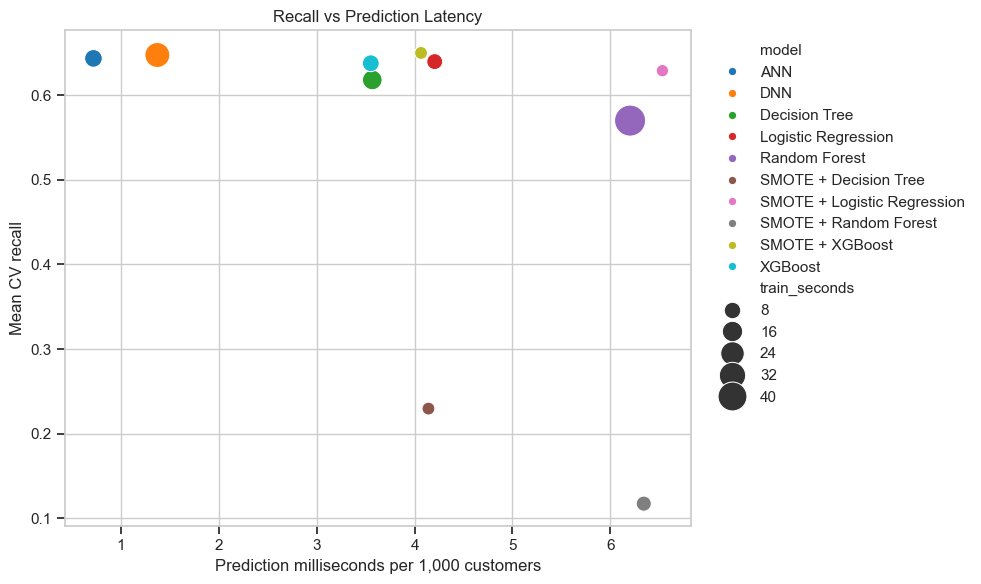

In [21]:
all_cv_parts = [ml_cv_results]
if "smote_cv_results" in globals() and not smote_cv_results.empty:
    all_cv_parts.append(smote_cv_results)
if "dl_cv_results" in globals() and not dl_cv_results.empty:
    all_cv_parts.append(dl_cv_results)

all_cv_results = pd.concat(all_cv_parts, ignore_index=True)
display(summarize_cv_results(all_cv_results).round(4))

tradeoff_df = (
    all_cv_results.groupby("model")
    .agg(
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        roc_auc=("roc_auc", "mean"),
        avg_precision=("avg_precision", "mean"),
        train_seconds=("train_seconds", "mean"),
        predict_ms_per_1000=("predict_ms_per_1000", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=tradeoff_df,
    x="predict_ms_per_1000",
    y="recall",
    size="train_seconds",
    hue="model",
    sizes=(80, 500),
    ax=ax,
)
ax.set_title("Recall vs Prediction Latency")
ax.set_xlabel("Prediction milliseconds per 1,000 customers")
ax.set_ylabel("Mean CV recall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Interpretation:

The best model for a bank is not automatically the highest-recall model. A useful model should
also score customers quickly enough for the retention workflow and remain interpretable enough
for business use.


In [22]:
def pairwise_wilcoxon(results_df, metric="recall"):
    '''Run pairwise Wilcoxon tests for models with the same fold count.'''
    rows = []
    pivot = results_df.pivot_table(index="fold", columns="model", values=metric)
    models = list(pivot.columns)

    for i, model_a in enumerate(models):
        for model_b in models[i + 1 :]:
            pair = pivot[[model_a, model_b]].dropna()
            if len(pair) < 2:
                continue
            try:
                stat, p_value = stats.wilcoxon(pair[model_a], pair[model_b])
            except ValueError:
                stat, p_value = np.nan, np.nan
            rows.append(
                {
                    "metric": metric,
                    "model_a": model_a,
                    "model_b": model_b,
                    "mean_a": pair[model_a].mean(),
                    "mean_b": pair[model_b].mean(),
                    "mean_diff_a_minus_b": pair[model_a].mean() - pair[model_b].mean(),
                    "p_value": p_value,
                }
            )

    return pd.DataFrame(rows).sort_values("p_value", na_position="last")


recall_tests = pairwise_wilcoxon(all_cv_results, metric="recall")
f1_tests = pairwise_wilcoxon(all_cv_results, metric="f1")

print("Pairwise Wilcoxon tests for recall")
display(recall_tests.round(5))

print("Pairwise Wilcoxon tests for F1")
display(f1_tests.round(5))


Pairwise Wilcoxon tests for recall


,metric,model_a,model_b,mean_a,mean_b,mean_diff_a_minus_b,p_value
22,recall,Decision Tree,SMOTE + XGBoost,0.61804,0.64990,-0.03187,0.25
24,recall,Logistic Regression,Random Forest,0.63965,0.56998,0.06968,0.25
25,recall,Logistic Regression,SMOTE + Decision Tree,0.63965,0.22977,0.40989,0.25
26,recall,Logistic Regression,SMOTE + Logistic Regression,0.63965,0.62894,0.01071,0.25
27,recall,Logistic Regression,SMOTE + Random Forest,0.63965,0.11750,0.52215,0.25
28,recall,Logistic Regression,SMOTE + XGBoost,0.63965,0.64990,-0.01025,0.25
30,recall,Random Forest,SMOTE + Decision Tree,0.56998,0.22977,0.34021,0.25
31,recall,Random Forest,SMOTE + Logistic Regression,0.56998,0.62894,-0.05896,0.25
32,recall,Random Forest,SMOTE + Random Forest,0.56998,0.11750,0.45247,0.25
23,recall,Decision Tree,XGBoost,0.61804,0.63775,-0.01971,0.25


Pairwise Wilcoxon tests for F1


,metric,model_a,model_b,mean_a,mean_b,mean_diff_a_minus_b,p_value
0,f1,ANN,DNN,0.25392,0.25333,0.00058,0.25
24,f1,Logistic Regression,Random Forest,0.25500,0.25901,-0.00401,0.25
25,f1,Logistic Regression,SMOTE + Decision Tree,0.25500,0.20521,0.04978,0.25
26,f1,Logistic Regression,SMOTE + Logistic Regression,0.25500,0.25057,0.00442,0.25
27,f1,Logistic Regression,SMOTE + Random Forest,0.25500,0.16263,0.09237,0.25
28,f1,Logistic Regression,SMOTE + XGBoost,0.25500,0.24978,0.00521,0.25
29,f1,Logistic Regression,XGBoost,0.25500,0.25620,-0.00121,0.25
30,f1,Random Forest,SMOTE + Decision Tree,0.25901,0.20521,0.05379,0.25
31,f1,Random Forest,SMOTE + Logistic Regression,0.25901,0.25057,0.00843,0.25
23,f1,Decision Tree,XGBoost,0.24452,0.25620,-0.01169,0.25


Interpretation:

With only a few CV folds, p-values are supportive rather than definitive. Use them as evidence of
consistency across folds, not as the only model-selection criterion.


## 14. Final Holdout Evaluation

This section fits selected final models on the full training partition and evaluates once on the
untouched holdout test set. If HPO was run, the best HPO model by recall is included.


In [23]:
final_candidates = {}

# In smoke-test mode, fit final models on the modelling sample to validate code quickly.
X_final_train = X_model if SMOKE_TEST else X_train_full
y_final_train = y_model if SMOKE_TEST else y_train_full

# Add the best base ML model by mean CV recall.
base_best_name = (
    ml_cv_results.groupby("model")["recall"].mean().sort_values(ascending=False).index[0]
)
final_candidates[f"Base {base_best_name}"] = make_ml_pipeline(
    build_ml_models(y_final_train)[base_best_name],
    use_smote=False,
)

# Add the best HPO model if available.
if "hpo_results" in globals() and not hpo_results.empty:
    best_hpo_row = hpo_results.sort_values("best_recall", ascending=False).iloc[0]
    best_key = (best_hpo_row["model"], best_hpo_row["search"])
    final_candidates[f"HPO {best_hpo_row['search']} {best_hpo_row['model']}"] = hpo_best_estimators[
        best_key
    ]

holdout_rows = []
fitted_final_models = {}

for model_name, pipeline in final_candidates.items():
    print(f"Fitting final model: {model_name}")
    fitted = clone(pipeline)

    fit_start = time.perf_counter()
    fitted.fit(X_final_train, y_final_train)
    fit_seconds = time.perf_counter() - fit_start

    pred_start = time.perf_counter()
    y_proba = predict_positive_probability(fitted, X_test)
    y_pred = (y_proba >= 0.50).astype(int)
    pred_seconds = time.perf_counter() - pred_start

    row = {
        "model": model_name,
        "train_seconds": fit_seconds,
        "predict_seconds": pred_seconds,
        "predict_ms_per_1000": pred_seconds / len(X_test) * 1000 * 1000,
    }
    row.update(metric_dict(y_test, y_pred, y_proba))
    holdout_rows.append(row)
    fitted_final_models[model_name] = fitted

holdout_results = pd.DataFrame(holdout_rows).sort_values("recall", ascending=False)
display(holdout_results.round(4))


Fitting final model: Base Logistic Regression
Fitting final model: HPO Optuna Decision Tree


,model,train_seconds,predict_seconds,predict_ms_per_1000,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,avg_precision
0,Base Logistic Regression,10.5048,0.8384,4.1920,0.6288,0.6338,0.1592,0.6401,0.2550,0.6850,0.2027
1,HPO Optuna Decision Tree,13.3428,0.6719,3.3593,0.6437,0.6061,0.1508,0.5592,0.2375,0.6516,0.1627


Interpretation:

This is the most important performance table because the test set has never influenced model
training or selection. Use it to support the final thesis conclusion about performance versus
execution-time trade-off.


,Pred non-churn,Pred churn
Actual non-churn,113067,67088
Actual churn,7143,12702


              precision    recall  f1-score   support

           0     0.9406    0.6276    0.7529    180155
           1     0.1592    0.6401    0.2550     19845

    accuracy                         0.6288    200000
   macro avg     0.5499    0.6338    0.5039    200000
weighted avg     0.8630    0.6288    0.7035    200000



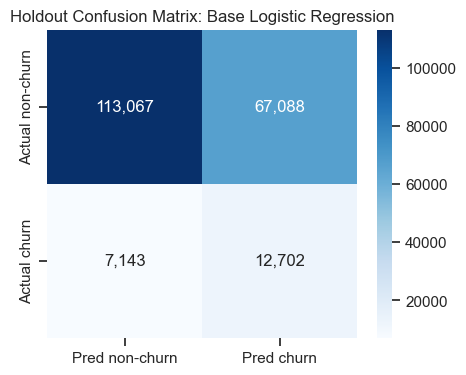

In [24]:
# Confusion matrix and classification report for the best holdout model.
best_holdout_name = holdout_results.iloc[0]["model"]
best_holdout_model = fitted_final_models[best_holdout_name]
best_proba = predict_positive_probability(best_holdout_model, X_test)
best_pred = (best_proba >= 0.50).astype(int)

cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(cm, index=["Actual non-churn", "Actual churn"], columns=["Pred non-churn", "Pred churn"])
display(cm_df)

print(classification_report(y_test, best_pred, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title(f"Holdout Confusion Matrix: {best_holdout_name}")
plt.show()


Interpretation:

False negatives are actual churners the model missed. In banking retention, this count is often
more costly than false positives, so the confusion matrix should be interpreted alongside recall
and business intervention cost.


## 15. Threshold Tuning for Business Trade-Offs

The default threshold of 0.50 may not be optimal for churn intervention. This section shows how
precision and recall change across thresholds, allowing the bank to choose a threshold based on
campaign budget and missed-churn cost.


,threshold,precision,recall,f1
0,0.0993,0.0992,1.0000,0.1805
10000,0.2161,0.1031,0.9874,0.1867
20000,0.2507,0.1070,0.9703,0.1927
30000,0.2801,0.1111,0.9521,0.1991
40000,0.3080,0.1153,0.9298,0.2052
50000,0.3347,0.1198,0.9053,0.2116
60000,0.3605,0.1244,0.8775,0.2179
70000,0.3859,0.1288,0.8437,0.2235
80000,0.4099,0.1338,0.8091,0.2296
90000,0.4326,0.1388,0.7694,0.2352


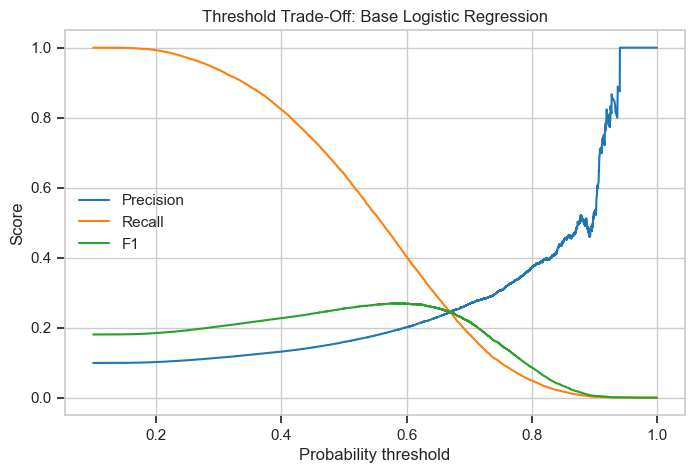

In [25]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_proba)
threshold_df = pd.DataFrame(
    {
        "threshold": np.r_[thresholds, 1.0],
        "precision": precision_vals,
        "recall": recall_vals,
    }
)
threshold_df["f1"] = (
    2
    * threshold_df["precision"]
    * threshold_df["recall"]
    / (threshold_df["precision"] + threshold_df["recall"]).replace(0, np.nan)
)

display(threshold_df.iloc[:: max(len(threshold_df) // 20, 1)].round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.set_title(f"Threshold Trade-Off: {best_holdout_name}")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score")
ax.legend()
plt.show()


Interpretation:

Lower thresholds usually increase recall but reduce precision. If the bank can afford more
retention offers, a lower threshold may be justified; if intervention budget is tight, a higher
threshold may be preferable.


## 16. Interpretability with SHAP

SHAP is applied to the best tree-based final model when available. The explanation uses transformed
features from the fitted pipeline, preserving the same preprocessing used during training.


Explaining: HPO Optuna Decision Tree


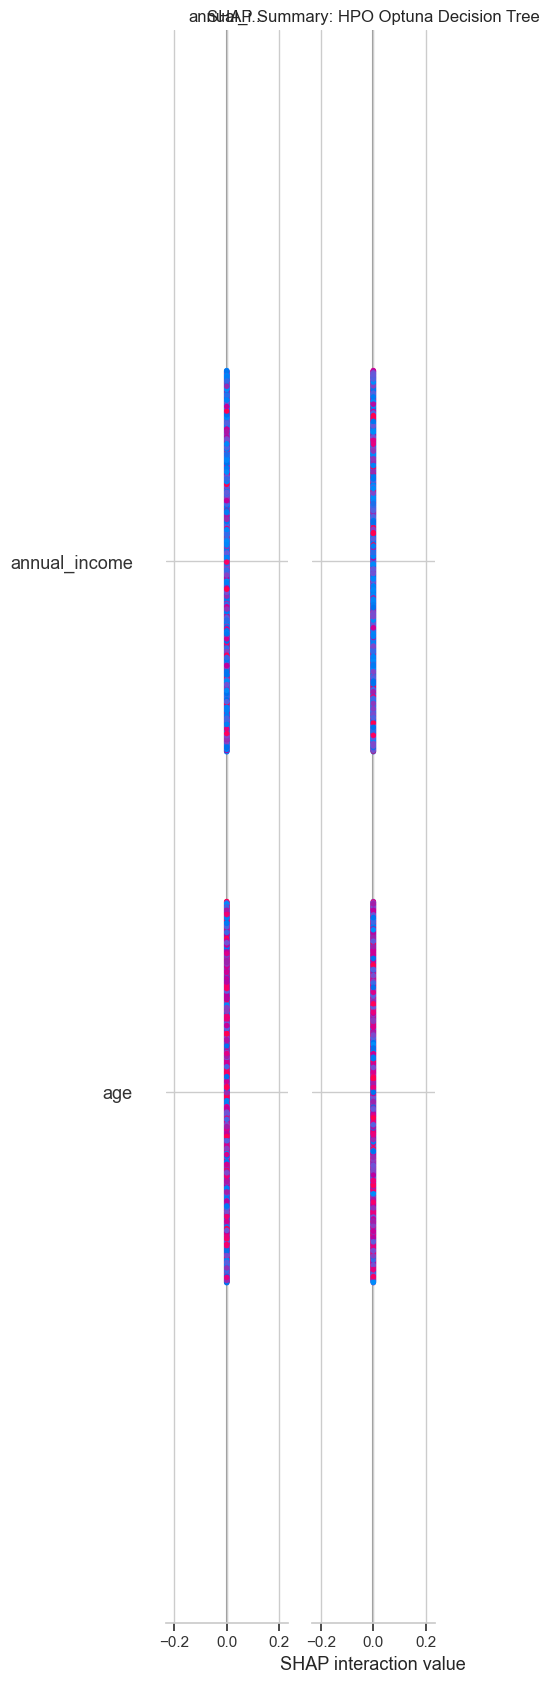

In [26]:
def get_transformed_matrix_and_names(fitted_pipeline, X_data):
    '''Transform X through feature engineering and preprocessing, returning matrix and names.'''
    engineered = fitted_pipeline.named_steps["feature_engineering"].transform(X_data)
    matrix = fitted_pipeline.named_steps["preprocess"].transform(engineered)
    try:
        names = fitted_pipeline.named_steps["preprocess"].get_feature_names_out()
    except Exception:
        names = np.array([f"feature_{i}" for i in range(matrix.shape[1])])
    return matrix, names


if RUN_SHAP:
    tree_model_name = None
    for candidate_name in fitted_final_models:
        estimator = fitted_final_models[candidate_name].named_steps["model"]
        if isinstance(estimator, (RandomForestClassifier, XGBClassifier, DecisionTreeClassifier)):
            tree_model_name = candidate_name
            break

    if tree_model_name is None:
        print("No tree-based final model found for SHAP. Consider permutation importance instead.")
    else:
        print(f"Explaining: {tree_model_name}")
        shap_model = fitted_final_models[tree_model_name]
        estimator = shap_model.named_steps["model"]

        X_explain = X_test.sample(n=min(1_000, len(X_test)), random_state=RANDOM_STATE)
        X_explain_matrix, feature_names = get_transformed_matrix_and_names(shap_model, X_explain)

        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_explain_matrix)

        # Some estimators return a list for binary classification; use the positive class.
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(
            shap_values_to_plot,
            X_explain_matrix,
            feature_names=feature_names,
            show=False,
            max_display=20,
        )
        plt.title(f"SHAP Summary: {tree_model_name}")
        plt.tight_layout()
        plt.show()
else:
    print("SHAP skipped by configuration.")


Interpretation:

The SHAP summary identifies the strongest global drivers of churn. Use it to check whether the
model's logic aligns with EDA and banking intuition, especially satisfaction, complaints, contract
type, payment behaviour, and support/service features.


## 17. Save Outputs

This section saves fold-level results and final holdout results so they can be used in the thesis
write-up.


In [ ]:
OUTPUT_DIR = Path("thesis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

all_cv_results.to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
tradeoff_df.to_csv(OUTPUT_DIR / "runtime_tradeoff_summary.csv", index=False)
holdout_results.to_csv(OUTPUT_DIR / "holdout_results.csv", index=False)

if "hpo_results" in globals() and not hpo_results.empty:
    hpo_results.to_csv(OUTPUT_DIR / "hpo_results.csv", index=False)

print(f"Saved outputs to: {OUTPUT_DIR.resolve()}")


Interpretation:

The saved CSV files preserve the numerical evidence for the thesis tables: cross-validation
metrics, runtime trade-offs, HPO results, and final holdout performance.


## 18. Methodology References

- Proposal: `01_Duc_Le_Research_proposal.pdf`.
- scikit-learn TargetEncoder documentation:
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html
  and internal cross-fitting example:
  https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder_cross_val.html
- imbalanced-learn common pitfalls:
  https://imbalanced-learn.org/dev/common_pitfalls.html
  and pipeline documentation:
  https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html
- Chawla et al. (2002): original SMOTE method for synthetic minority oversampling.
- Molnar (2020): interpretable machine learning and SHAP-style model interpretation.

These references support the notebook's leakage-safe target encoding, fold-local resampling,
class-imbalance treatment, and interpretability workflow.
